# Exercice 1

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# Wczytanie danych
df = pd.read_csv('trees.csv')

# Ustawienie modelu Isolation Forest
iso_forest = IsolationForest()
iso_scores = iso_forest.fit_predict(df)
print(iso_scores)

df['iso_outlierness'] = iso_forest.decision_function(df)
df['iso_scores'] = iso_scores

print(df.head())

# Znalezienie i opisanie najbardziej odstających punktów
most_outlying = np.argmin(df['iso_outlierness'])  # Najbardziej odstający według Isolation Forest
df.iloc[most_outlying]

[-1 -1 -1  1  1  1 -1  1  1  1  1  1  1  1  1  1 -1 -1  1 -1  1  1  1 -1
  1 -1 -1 -1  1  1 -1]
   Diameter  Height  Volume  iso_outlierness  iso_scores
0       8.3      70    10.3        -0.076557          -1
1       8.6      65    10.3        -0.062022          -1
2       8.8      63    10.2        -0.111177          -1
3      10.5      72    16.4         0.029035           1
4      10.7      81    18.8         0.034716           1


Diameter           20.600000
Height             87.000000
Volume             77.000000
iso_outlierness    -0.225299
iso_scores         -1.000000
Name: 30, dtype: float64

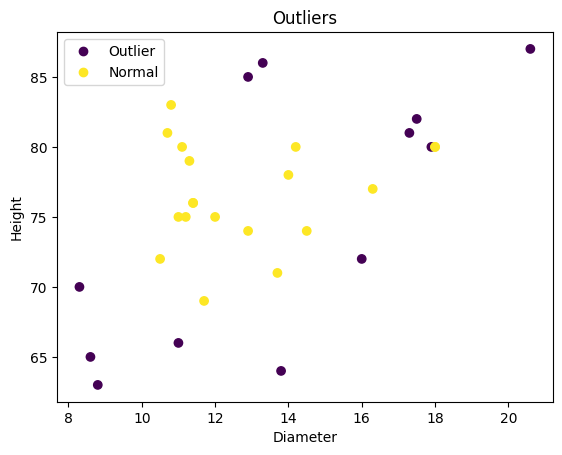

In [3]:
scatter = plt.scatter(df['Diameter'],
            df['Height'],
            c = df['iso_scores'])
plt.xlabel('Diameter')
plt.ylabel('Height')
plt.title('Outliers')
plt.legend(handles = scatter.legend_elements()[0],
           labels = ['Outlier', 'Normal'])
plt.show()